## Подготовка и анализ данных

In [10]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import math
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline

### Загрузка датасета

In [11]:
dataset = load_dataset("inria-soda/tabular-benchmark", data_files="clf_cat/electricity.csv")

Generating train split: 38474 examples [00:00, 1397435.44 examples/s]


In [12]:
df = dataset['train'].to_pandas()
df.head()

,date,day,period,nswprice,nswdemand,vicprice,vicdemand,transfer,class
0,0.898987,2,0.957447,0.068632,0.568283,0.004456,0.456499,0.644737,DOWN
1,0.867616,5,0.234043,0.033716,0.337102,0.001672,0.329622,0.846930,DOWN
2,0.009159,6,0.255319,0.059175,0.185808,0.003467,0.422915,0.414912,DOWN
3,0.898987,2,0.531915,0.087577,0.539572,0.004936,0.637752,0.491667,DOWN
4,0.868280,6,0.085106,0.027021,0.165129,0.001271,0.265924,0.748246,DOWN


In [13]:
df['class'].value_counts()

class
DOWN    19237
UP      19237
Name: count, dtype: int64

Переведем целевой признак в числовой формат

In [14]:
df['class_num'] = df['class'].map({'DOWN': 0, 'UP': 1})
df = df.drop(columns='class')

---
Задача: \
Предсказать, вырастет ли цена за электроэнергию или нет. \
Бинарная классификация. \
Целевая переменная - class_num

---

### Пропуски

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38474 entries, 0 to 38473
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       38474 non-null  float64
 1   day        38474 non-null  int64  
 2   period     38474 non-null  float64
 3   nswprice   38474 non-null  float64
 4   nswdemand  38474 non-null  float64
 5   vicprice   38474 non-null  float64
 6   vicdemand  38474 non-null  float64
 7   transfer   38474 non-null  float64
 8   class_num  38474 non-null  int64  
dtypes: float64(7), int64(2)
memory usage: 2.6 MB


Пропусков в данных нет

### Анализ распределений

In [16]:
df.describe()

,date,day,period,nswprice,nswdemand,vicprice,vicdemand,transfer,class_num
count,38474.000000,38474.000000,38474.000000,38474.000000,38474.000000,38474.000000,38474.000000,38474.000000,38474.000000
mean,0.498378,2.984951,0.506960,0.060176,0.434220,0.003568,0.427452,0.497235,0.500000
std,0.340142,2.001691,0.290737,0.042388,0.162010,0.010905,0.121001,0.152075,0.500006
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.031901,1.000000,0.255319,0.036268,0.321333,0.002360,0.382444,0.414912,0.000000
50%,0.456263,3.000000,0.510638,0.051189,0.452246,0.003467,0.422915,0.414912,0.500000
75%,0.880536,5.000000,0.765957,0.075868,0.542101,0.003467,0.477991,0.599123,1.000000
max,1.000000,6.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


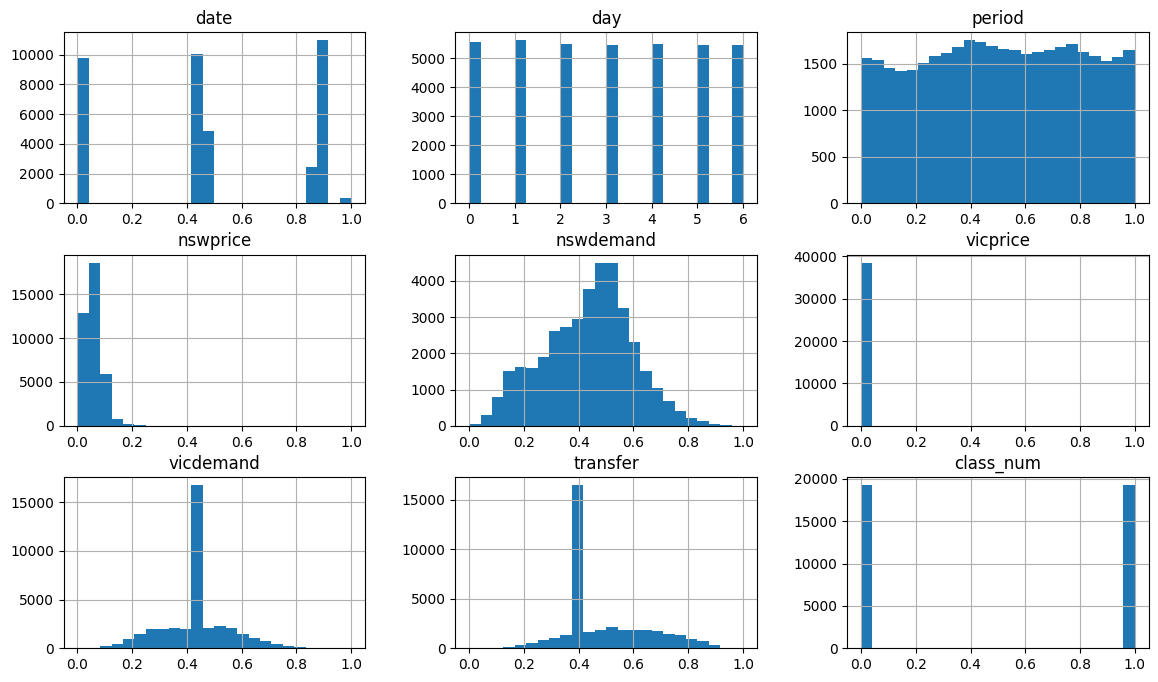

In [17]:
df.hist(figsize=(14, 8), bins=24);

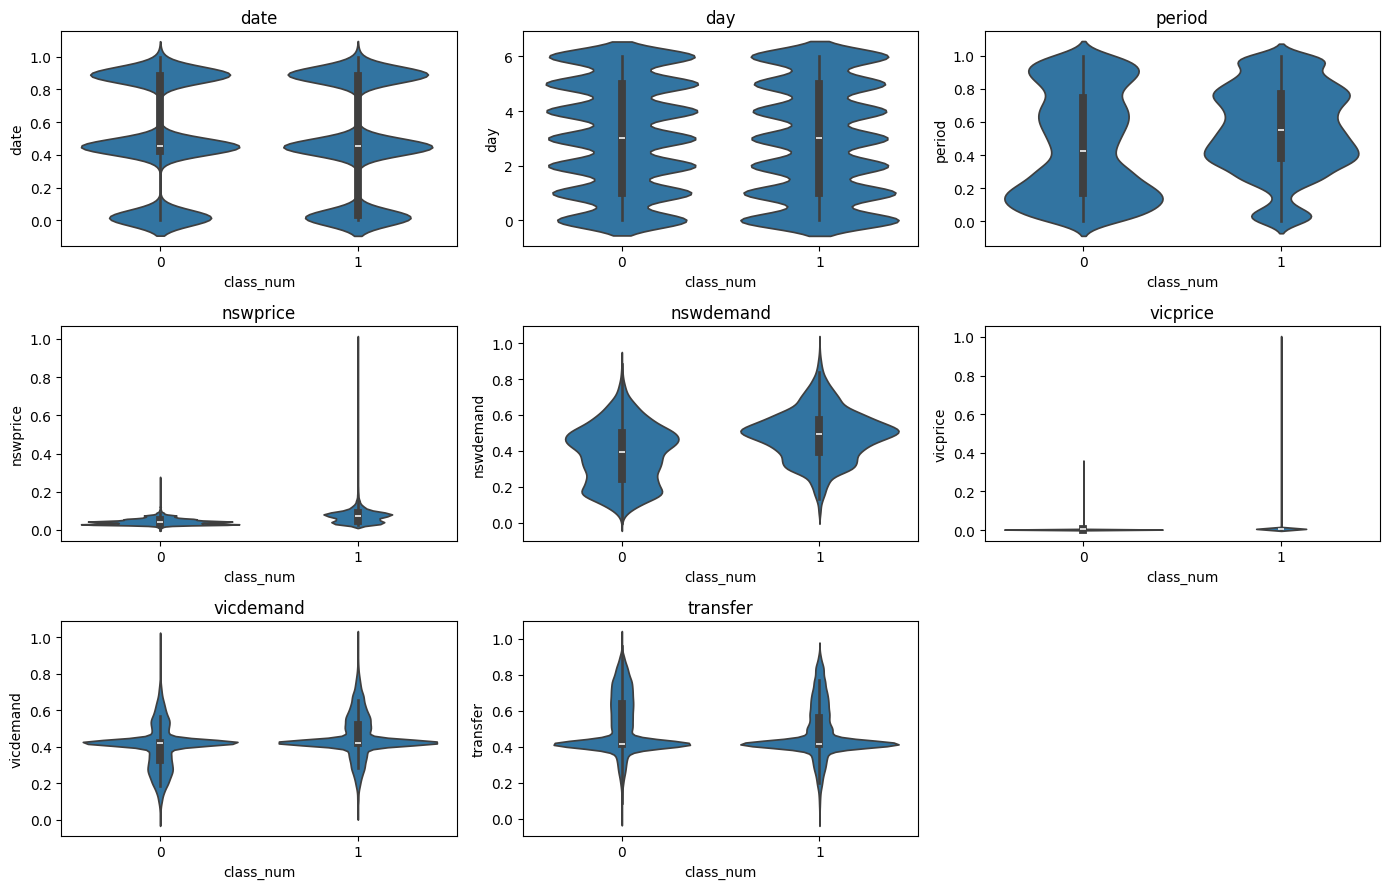

In [18]:
cols = df.columns.drop('class_num')
n = len(cols)

rows = math.ceil(n / 3)
plt.figure(figsize=(14, 3 * rows))

for i, col in enumerate(cols, 1):
    plt.subplot(rows, 3, i)
    sns.violinplot(x=df['class_num'], y=df[col])
    plt.title(col)
    plt.tight_layout()

#### `nswprice`

<Axes: >

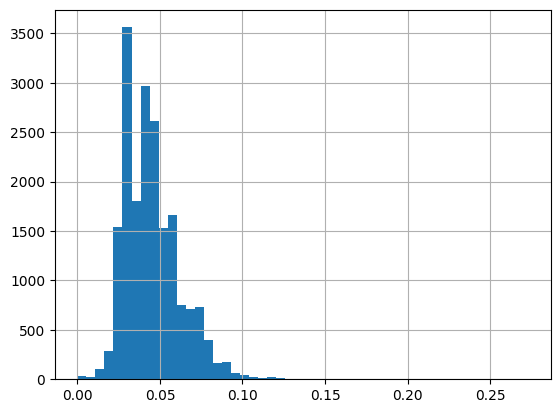

In [19]:
df.query('class_num == 0')['nswprice'].hist(bins=50)

<Axes: >

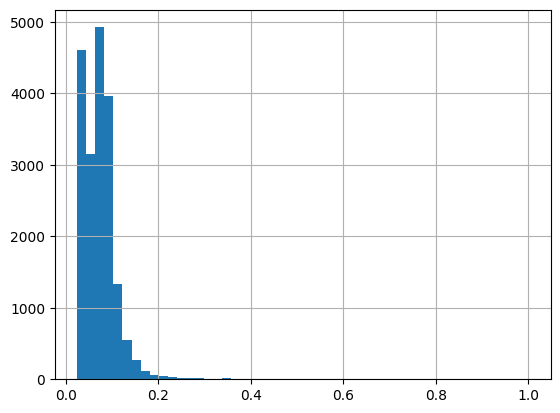

In [20]:
df.query('class_num == 1')['nswprice'].hist(bins=50)

In [21]:
len(df.query('nswprice > 0.2'))

248

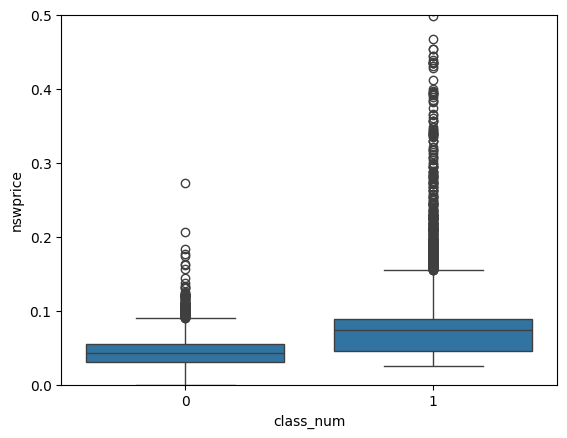

In [22]:
sns.boxplot(x=df['class_num'], y=df['nswprice'])
plt.ylim(0, 0.5);

При class_num == 1 в признаке nswprice наблюдается значительно больше аномально больших значений. Это может указывать на наличие важной информации, связанной с особенностями класса, поэтому удалять такие выбросы не следует.

<Axes: >

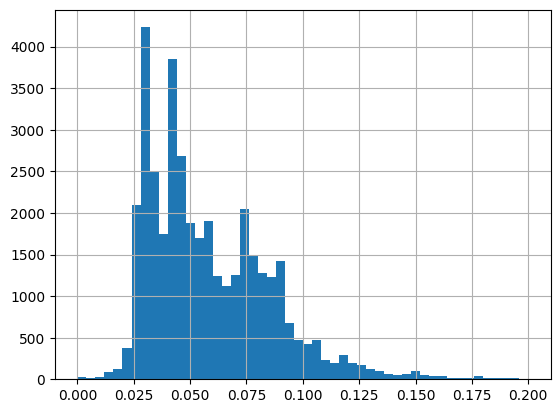

In [23]:
df['nswprice'].hist(bins=50, range=(0, 0.2))

<Axes: >

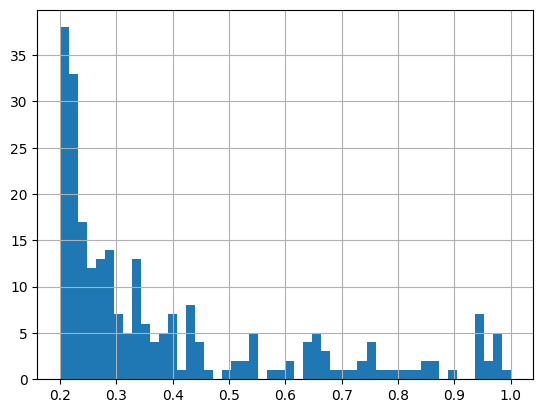

In [24]:
df['nswprice'].hist(bins=50, range=(0.2, 1))

In [25]:
df['nswprice'].value_counts()

nswprice
0.074817    351
0.055242    209
0.058394    205
0.028942    177
0.041732    162
           ... 
0.262910      1
0.135553      1
0.170590      1
0.123364      1
0.096613      1
Name: count, Length: 4041, dtype: int64

In [26]:
Q1 = df['nswprice'].quantile(0.25) 
Q3 = df['nswprice'].quantile(0.75) 
IQR = Q3 - Q1 
outliers = df[(df['nswprice'] < Q1 - 1.5 * IQR) | (df['nswprice'] > Q3 + 1.5 * IQR)]

print('Количество выбросов:', len(outliers))
print(f'Доля выбросов: {(len(outliers) / len(df)) * 100:.2f}%')

Количество выбросов: 822
Доля выбросов: 2.14%


Распределение `nswprice` сильно скошено и содержит экстремальные значения.
Однако, так как это реальные рыночные цены, выбросы являются закономерной частью данных и не требуют удаления.

#### `vicprice`

<Axes: >

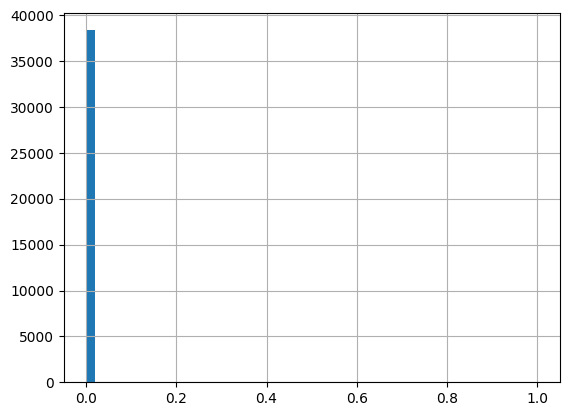

In [27]:
df['vicprice'].hist(bins=50)

<Axes: >

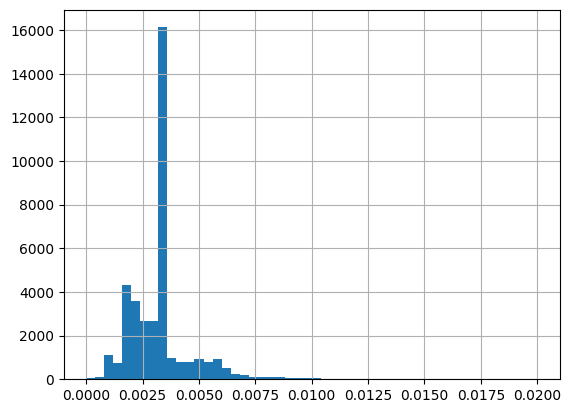

In [28]:
df['vicprice'].hist(bins=50, range=(0, 0.02))

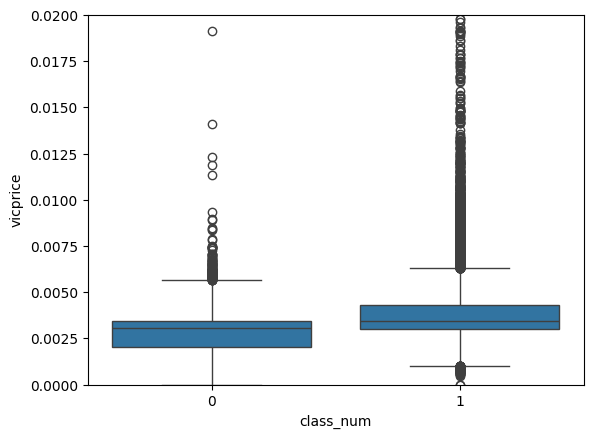

In [29]:
sns.boxplot(x=df['class_num'], y=df['vicprice'])
plt.ylim(0, 0.02);

Ситуация аналогична: аномально большие значения снова чаще встречаются при class_num == 1, что подтверждает связь выбросов с этим классом.

In [30]:
df['vicprice'].value_counts()

vicprice
0.003467    14879
0.000841      169
0.002009      107
0.000976       74
0.000839       70
            ...  
0.019144        1
0.012545        1
0.030500        1
0.014819        1
0.005675        1
Name: count, Length: 3764, dtype: int64

В столбце `vicprice` наблюдается сильная концентрация значений на уровне 0.003467 — этот тариф встречается примерно в половине записей, образуя выраженный пик распределения. Скорее всего, это результат импутации или реальная особенность данных.

In [31]:
vicprice_mode = df.vicprice.mode().item()

df.query('vicprice == @vicprice_mode')['class_num'].value_counts()

class_num
1    7610
0    7269
Name: count, dtype: int64

Признак `vicprice` со значением 0.003467 не демонстрирует выраженной зависимости с целевым классом. Распределение классов при этом значении практически симметрично и совпадает с общим балансом выборки.

#### `vicdemand`

<Axes: >

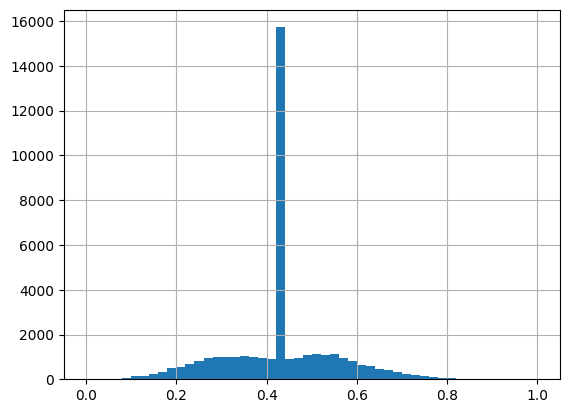

In [32]:
df['vicdemand'].hist(bins=50)

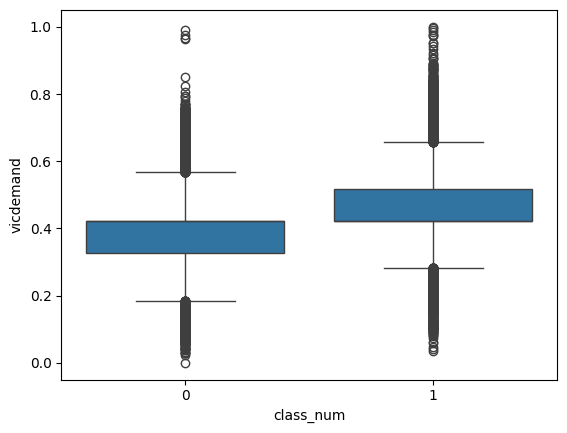

In [33]:
sns.boxplot(x=df['class_num'], y=df['vicdemand']);

Разница в уровнях boxplot показывает сдвиг распределений: класс 1 имеет более высокие типичные значения признака. Это может быть слабым, но всё-таки признаком разделимости.

In [34]:
df['vicdemand'].value_counts()

vicdemand
0.422915    14878
0.562144       26
0.494562       25
0.551010       25
0.516054       24
            ...  
0.809684        1
0.874676        1
0.889177        1
0.883221        1
0.738995        1
Name: count, Length: 2799, dtype: int64

Половина всех значений сконцентрированы в одной точке, так же, как в столбце `vicprice`.

#### `transfer`

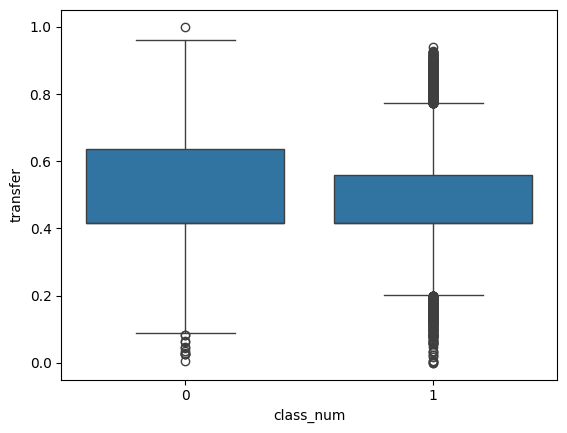

In [35]:
sns.boxplot(x=df['class_num'], y=df['transfer']);

У класса 0 межквартильный размах значительно шире, что показывает высокую вариативность признака. Значения внутри этого класса распределены гораздо неравномернее, чем у класса 1.

In [36]:
df['transfer'].value_counts()

transfer
0.414912    14930
0.500526      293
0.765789      177
0.838158       60
0.634211       51
            ...  
0.033333        1
0.006579        1
0.018421        1
0.067544        1
0.900000        1
Name: count, Length: 1858, dtype: int64

Снова одно и то же значение в половине записей

### Корреляционный анализ

<Axes: >

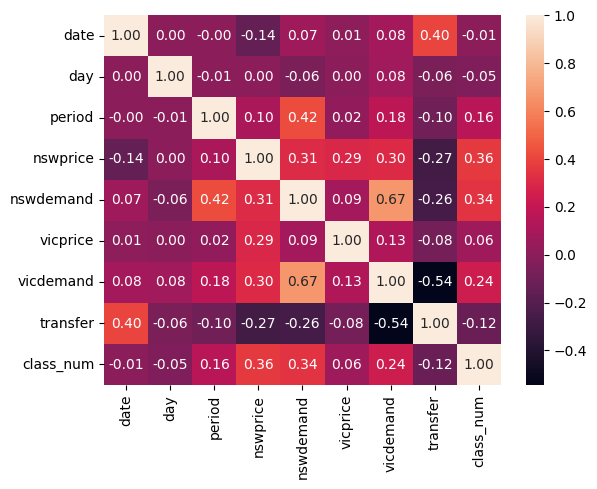

In [37]:
sns.heatmap(df.corr(), annot=True, fmt=".2f")

Корреляционная матрица показала, что:

- между числовыми признаками нет сильной линейной связи
- максимальные значения - около 0.67 и -0.54, что считается умеренной корреляцией
- зависимости с таргетом, скорее всего, нелинейные

### Поиск дубликатов

In [38]:
df.duplicated().sum()

np.int64(0)

Явных дубликатов в данных нет

### Подготовка к обучению

Будем использовать RobustScaler, так как данные содержат много выбросов

In [39]:
X = df.drop(columns='class_num')
y = df['class_num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape, y_train.value_counts()

((30779, 8),
 class_num
 1    15390
 0    15389
 Name: count, dtype: int64)

### Вывод

Целевая переменная (0,1) сбалансирована, что упрощает обучение моделей.
В числовых признаках (nswprice, vicprice, transfer, nswdemand, vicdemand) встречаются большие значения, которые выглядят как выбросы, но на практике они связаны с часовыми скачками цен и спроса. Эти значения чаще наблюдаются при классе UP, поэтому удалять их нельзя — они несут сигнал.

В нескольких признаках обнаружены доминирующие повторяющиеся значения (например, vicprice = 0.003467), что связано со спецификой источника данных, а не ошибками. Это особенность тарификации/нормализации, а не проблема качества данных.

Корреляции между признаками слабые, поэтому связь с целевой переменной, вероятно, нелинейная. Это означает, что модели вроде Random Forest или градиентного бустинга подойдут лучше линейных.

В целом данные чистые, пропусков нет, удаление выбросов не требуется. Признаки различаются по распределению между классами, значит информация для классификации действительно есть.

## Построение baseline-моделей

### Сравнение RandomForest и LogisticRegression

In [40]:
logres_model = LogisticRegression(random_state=123)
forest_model = RandomForestClassifier(random_state=123, n_jobs=-1)

logres_model.fit(X_train_scaled, y_train)
forest_model.fit(X_train_scaled, y_train)

logres_preds = logres_model.predict(X_test_scaled)
forest_preds = forest_model.predict(X_test_scaled)

print('Результаты:')
print(f'Логистическая регрессия:\n accuracy = {accuracy_score(y_test, logres_preds)}, f1-macro = {f1_score(y_test, logres_preds, average='macro')}')
print(f'Случайный лес:\n accuracy = {accuracy_score(y_test, forest_preds)}, f1-macro = {f1_score(y_test, forest_preds, average='macro')}')

Результаты:
Логистическая регрессия:
 accuracy = 0.7406107862248213, f1-macro = 0.7393318518846381
Случайный лес:
 accuracy = 0.9018843404808317, f1-macro = 0.9018841747810973


### Анализ результатов

In [41]:
print('Логистическая регрессия:')
print(classification_report(y_test, logres_preds))
print()
print('Случайный лес:')
print(classification_report(y_test, forest_preds))

Логистическая регрессия:
              precision    recall  f1-score   support

           0       0.71      0.81      0.76      3848
           1       0.78      0.67      0.72      3847

    accuracy                           0.74      7695
   macro avg       0.75      0.74      0.74      7695
weighted avg       0.75      0.74      0.74      7695


Случайный лес:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      3848
           1       0.90      0.90      0.90      3847

    accuracy                           0.90      7695
   macro avg       0.90      0.90      0.90      7695
weighted avg       0.90      0.90      0.90      7695



### Features Importance

     feature  importance
3   nswprice    0.301974
0       date    0.179450
4  nswdemand    0.139301
2     period    0.108113
5   vicprice    0.099361
6  vicdemand    0.061469
7   transfer    0.055875
1        day    0.054457


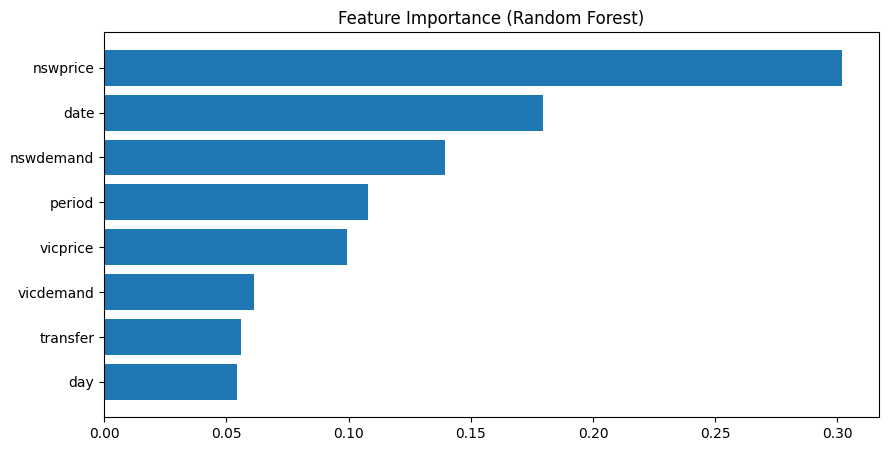

In [42]:
importances = forest_model.feature_importances_
feature_names = X_train.columns

fi = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi = fi.sort_values('importance', ascending=False)

print(fi)

plt.figure(figsize=(10, 5))
plt.barh(fi['feature'], fi['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.show()

### Вывод

Гипотеза о нелинейной зависимости признаков и целевой переменной подтвердилась, случайный лес справился лучше логистической регрессии. Он одинаково хорошо (с точностью 0.9) предсказывает оба класса. Логистическая регрессия же класс 0 предсказывает немного лучше класса 1 (0.76 против 0.72 по метрике f1-score), но разница незначительна.

## Эксперименты

### Изменение гиперпараметров логистической регрессии

In [43]:
logres_model = LogisticRegression(penalty='l1', solver='liblinear', random_state=123)

logres_model.fit(X_train_scaled, y_train)
logres_preds = logres_model.predict(X_test_scaled)

print('Результаты:')
print(f'Логистическая регрессия:\n accuracy = {accuracy_score(y_test, logres_preds)}, f1-macro = {f1_score(y_test, logres_preds, average='macro')}')

Результаты:
Логистическая регрессия:
 accuracy = 0.7403508771929824, f1-macro = 0.7390706613554645


/Users/mikhail/hse/ds/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/mikhail/hse/ds/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Качество модели практически не поменялось

### Поиск оптимальных гиперпараметров случайного леса с помощью GridSearch

In [44]:
pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('clf', RandomForestClassifier(random_state=123, n_jobs=-1))
])

params = {
    'clf__n_estimators': [100, 140, 180],
    'clf__max_depth': [None],
    'clf__max_features': [None, 'sqrt']
}

grid_search = GridSearchCV(pipeline, params, scoring='f1_macro', n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучший score (кросс‑валидация):", grid_search.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END clf__max_depth=None, clf__max_features=None, clf__n_estimators=100; total time=   7.2s
[CV] END clf__max_depth=None, clf__max_features=None, clf__n_estimators=100; total time=   7.3s
[CV] END clf__max_depth=None, clf__max_features=None, clf__n_estimators=100; total time=   7.4s
[CV] END clf__max_depth=None, clf__max_features=None, clf__n_estimators=100; total time=   7.4s
[CV] END clf__max_depth=None, clf__max_features=None, clf__n_estimators=100; total time=   7.7s
[CV] END clf__max_depth=None, clf__max_features=None, clf__n_estimators=140; total time=   9.8s
[CV] END clf__max_depth=None, clf__max_features=None, clf__n_estimators=140; total time=   9.8s
[CV] END clf__max_depth=None, clf__max_features=None, clf__n_estimators=140; total time=   9.8s
[CV] END clf__max_depth=None, clf__max_features=None, clf__n_estimators=140; total time=   9.8s
[CV] END clf__max_depth=None, clf__max_features=sqrt, clf__n_estimators=100;

/Users/mikhail/hse/ds/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/mikhail/hse/ds/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/mikhail/hse/ds/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/mikhail/hse/ds/venv/lib/python3.14/site-packages/sklea

[CV] END clf__max_depth=None, clf__max_features=sqrt, clf__n_estimators=140; total time=   2.8s
[CV] END clf__max_depth=None, clf__max_features=sqrt, clf__n_estimators=140; total time=   3.0s
[CV] END clf__max_depth=None, clf__max_features=sqrt, clf__n_estimators=180; total time=   3.2s
[CV] END clf__max_depth=None, clf__max_features=sqrt, clf__n_estimators=180; total time=   3.2s
[CV] END clf__max_depth=None, clf__max_features=sqrt, clf__n_estimators=180; total time=   3.3s
[CV] END clf__max_depth=None, clf__max_features=sqrt, clf__n_estimators=180; total time=   1.9s
[CV] END clf__max_depth=None, clf__max_features=sqrt, clf__n_estimators=180; total time=   1.7s
[CV] END clf__max_depth=None, clf__max_features=None, clf__n_estimators=180; total time=   6.6s
Лучшие параметры: {'clf__max_depth': None, 'clf__max_features': None, 'clf__n_estimators': 100}
Лучший score (кросс‑валидация): 0.9109728158403959


In [45]:
best_forest_model = grid_search.best_estimator_
y_preds = best_forest_model.predict(X_test)
print(f'Качество на тестовой выборке:\n accuracy = {accuracy_score(y_test, y_preds)}, f1-macro = {f1_score(y_test, y_preds, average='macro')}')

Качество на тестовой выборке:
 accuracy = 0.9194282001299545, f1-macro = 0.9194278068826274


Подобрав оптимальные гиперпаратры, нам удалось достичь небольшого прироста качества модели случайного леса (на ~1%)

### Удаление признаков

Попробуем убрать признак `vicprice`, так как он содержит много аномалий

In [46]:
df2 = df.drop(columns=['vicprice', 'vicdemand', 'transfer'])

X2 = df2.drop(columns='class_num')
y2 = df2['class_num']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=123, stratify=y)

best_forest_model.fit(X_train2, y_train2)
y_preds2 = best_forest_model.predict(X_test2)

print(f'Качество на тестовой выборке:\n accuracy = {accuracy_score(y_test2, y_preds2)}, f1-macro = {f1_score(y_test2, y_preds2, average='macro')}')

Качество на тестовой выборке:
 accuracy = 0.9220272904483431, f1-macro = 0.9220261829896361


Удаление признаков с аномальными значениями (`transfer`, `vicdemand` и `vicprice`) немного улучшило качество модели (менее чем на 1%)

## Выводы

Сравнение моделей показало, что случайный лес уверенно обгоняет логистическую регрессию. Логистическая регрессия держится на уровне около 0.74 по F1-macro и явно не улавливает нелинейные зависимости, в то время как случайный лес стабильно выдаёт около 0.90. После подбора гиперпараметров удалось выжать ещё примерно +1% качества, что логично: лес хорошо реагирует на тонкую настройку глубины, количества деревьев и ограничений на разбиения.

По важности признаков видно, что ключевую роль играют ценовые и спросовые метрики регионов (например: `nswprice`, `nswdemand`), а так же дата (`date`). Признаки `vicprice`, `vicdemand` и `transfer` оказались малоинформативными: почти половина записей содержит одно и то же значение, из-за чего распределение искажается, а вариативность признака резко снижается. Удаление этих признаков дало небольшой прирост, что подтверждает их низкую информативность.

Ошибки случайного леса распределяются по классам примерно равномерно — модель одинаково хорошо предсказывает и 0, и 1. Это прямой признак того, что баланс классов нормальный, а само дерево не склонно переобучаться на одну сторону. Основные ошибки — редкие граничные случаи, когда признаки «ведут себя» как противоположный класс (обычно высокие пики цен или спроса). Но их мало, и природа ошибок скорее случайная, чем систематическая.